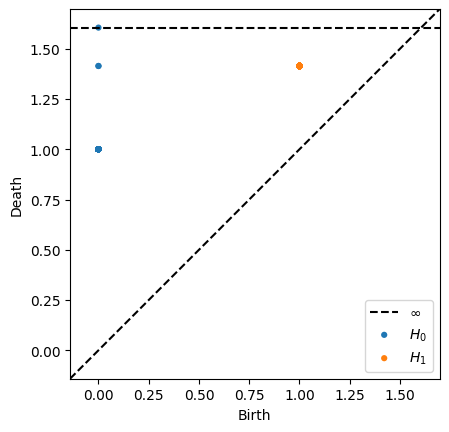

In [16]:
# installations
!pip install ripser
!pip install persim

# lib import
import numpy as np
import ripser
from persim import plot_diagrams



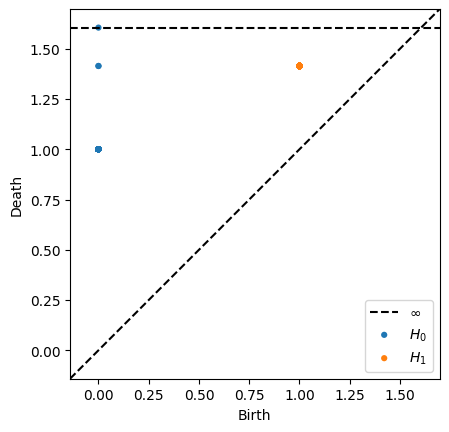

In [21]:
# random seed
np.random.seed(345)

# generate data on household types
n_units = 1000
n_household_types = 5
min_households_per_unit = 1
max_households_per_unit = 5

assert 1 <= min_households_per_unit <= max_households_per_unit
# assign distinct household types to each unit
assignments = []
for i in range(n_units):
    n_types = np.random.randint(
        min_households_per_unit,
        max_households_per_unit + 1
    )

    unit_types = np.random.choice(
        n_household_types,
        size=n_types,
        replace=False
    )

    assignments.append(unit_types)

# multi-hot encoding: presence or absence of each type
X = np.zeros((n_units, n_household_types), dtype=float)

for i, unit_types in enumerate(assignments):
    X[i, unit_types] = 1.0

# persistent homology of the unit-level feature vectors
result = ripser.ripser(X, maxdim=1, metric="euclidean")

diagrams = result["dgms"]
diagrams = ripser.ripser(onehot_assignments)["dgms"]

plot_diagrams(diagrams, show=True)



In [22]:
for dimension, diagram in enumerate(diagrams):
    print(f"\nH{dimension}: {len(diagram)} diagram entries")

    # Group matching coordinates for readable output
    pairs, multiplicities = np.unique(
        np.round(diagram, decimals=6),
        axis=0,
        return_counts=True
    )

    for (birth, death), count in zip(pairs, multiplicities):
        death_label = "infinity" if np.isinf(death) else f"{death:.6f}"

        print(
            f"  birth={birth:.6f}, "
            f"death={death_label}, "
            f"number of features={count}"
        )


H0: 424 diagram entries
  birth=0.000000, death=1.000000, number of features=421
  birth=0.000000, death=1.414214, number of features=2
  birth=0.000000, death=infinity, number of features=1

H1: 814 diagram entries
  birth=1.000000, death=1.414214, number of features=814


In [25]:
unique_profiles, profile_frequencies = np.unique(
    onehot_assignments,
    axis=0,
    return_counts=True
)

print("Total units:", onehot_assignments.shape[0])
print("Distinct count profiles:", len(unique_profiles))
print("H0 diagram entries:", len(diagrams[0]))

Total units: 1000
Distinct count profiles: 424
H0 diagram entries: 424
